# PREDICTING HIGH PAYING DATA SCIENCE ROLES IN 2026

## PROBLEM STATEMENT
* In a competitive AI job market,companies struggle to benchmark salaries.Can we predict whether an AI/Data Science role will be "High Paying" > $150k or "Standard Paying" <= $150k based on job title, experience, location and remote status.


## AIMS OF THE PROJECT

1. **Analyse salary trends**:Explore how salary varies by job title, experience level, location, company size and remote status.
1. **Build predictive models**:Develop and compare classification models to predict salary level using role and profile features. 
1. **Identify key drivers**:Determine the top 3 factors that most influence whether a role is high paying.
1. **Provide actionable insights**:Offer recommendations for job seekers, HR teams and companies on how to position roles and careers for competitive compensation in 2026.


## DATA UNDERSTANDING

**Data Source**:[Kaggle](https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026)

**Dataset Description**:This dataset contains 2026 AI and Data Science job postings with salary, job title, experience level, location, and remote status.Used to predict if a role is "High paying" > $150k.

**Key Columns**
1. 'job_title':Role name
1. 'experience_level':EN,MI,SE,EX
1. 'salary':Annual salary in USD
1. 'location': Job location
1. 'remote_ratio ':0,50,100
1. 'company_size':S,M,L

In [1]:
#Import the necessary libraries for cleaning and visualizing the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
#Load the dataset into a pandas DataFrame
df = pd.read_csv('AI AND DS.csv')
df.head(10)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1
5,Analytics Engineer,Senior,Full-time,M,SG,SG,Finance,100,11.6,Masters,...,17.4,SGD,97827,0.131,12.2,7.9,3,False,12.2,4.3
6,Business Intelligence Analyst,Senior,Full-time,M,US,US,Technology,0,9.8,Bachelors,...,0.5,USD,120062,0.039,13.0,5.5,6,False,10.9,6.4
7,Data Analyst,Entry,Full-time,M,US,US,Retail,0,1.4,Masters,...,4.2,USD,64165,0.187,12.7,7.3,3,True,14.5,6.4
8,Research Scientist,Mid,Full-time,M,AU,AU,Finance,0,2.2,Masters,...,6.6,AUD,112968,0.036,11.0,7.7,3,False,3.0,2.3
9,Data Engineer,Entry,Part-time,L,GB,GB,Healthcare,0,2.8,Self-taught,...,2.0,GBP,26464,0.044,0.0,6.2,5,False,9.3,5.4


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   str    
 1   experience_level            5000 non-null   str    
 2   employment_type             5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   company_location            5000 non-null   str    
 5   employee_residence          5000 non-null   str    
 6   industry                    5000 non-null   str    
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   str    
 10  primary_language            5000 non-null   str    
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 non-null   

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


## DATA CLEANING

#### Handling missing values

In [4]:
#Check for missing values in the dataset and remove them if necessary
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()



job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

#### Handling duplicates 

In [5]:
#Check for duplicate rows in the dataset and remove them if necessary
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

#### Checking for the duplicates

In [6]:
#Check the data types of each column in the dataset
print(df.dtypes)

job_title                         str
experience_level                  str
employment_type                   str
company_size                      str
company_location                  str
employee_residence                str
industry                          str
remote_ratio                    int64
years_experience              float64
education_level                   str
primary_language                  str
has_ml_in_title                  bool
manages_people                   bool
team_size                       int64
certifications_count            int64
weekly_hours                  float64
uses_ai_tools_daily              bool
ai_tools_hours_per_week       float64
salary_currency                   str
salary_usd                      int64
equity_offered_pct            float64
bonus_pct                     float64
job_satisfaction_score        float64
interviews_to_offer             int64
switched_jobs_last_year          bool
upskilling_hours_per_month    float64
fears_ai_aut

## EXPLORATORY DATA ANALYSIS

#### Univariate EDA
1. Histogram
1. Bar graph
1. pie Chart

#### Bivariate EDA
1. Box plot
1. Count plot
1. Scatter plot


#### Multivariate EDA
1. Pair plot
1. Heatmap




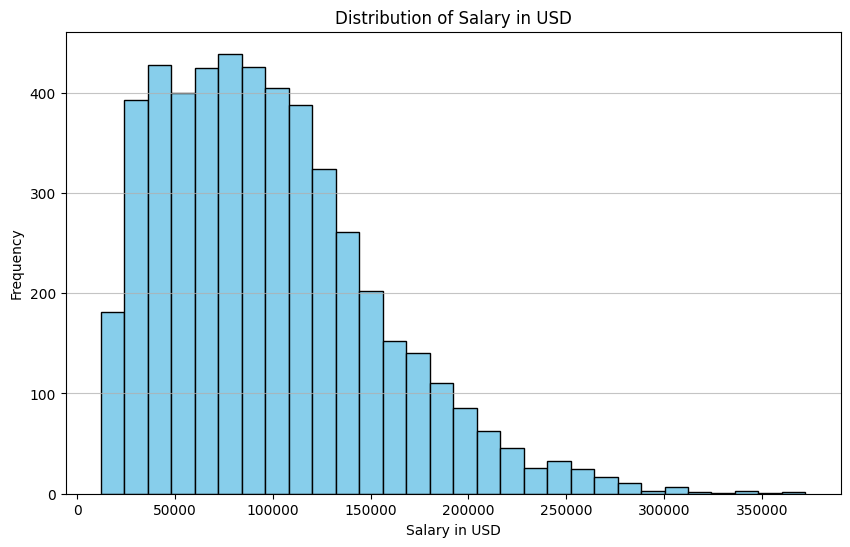

In [7]:
#Histogram of the 'Salary_USD' column
plt.figure(figsize=(10, 6))
plt.hist(df['salary_usd'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Salary in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Findings
1. **Most AI and Data Science jobs pay between $40k-$100k**:High paying jobs > $150k are uncommon and form a long right tail,making them a distinct minority class worth predicting.
1. **The market rate for most AI and Data Science roles sits between $50k-$100k**:Paying >$150k, puts the company in the top ~15-20% of payers which might end up making the company run bankrupt.

C:\Users\frkuhn\AppData\Local\Temp\ipykernel_15852\2197104212.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='job_title', y='salary_usd', data=df, estimator=np.mean, ci=None)


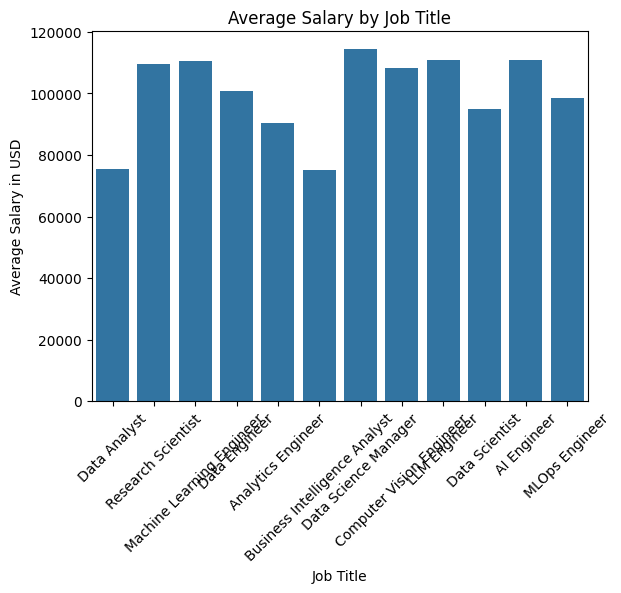

In [8]:
#Bar plot of the average salary by job title
sns.barplot(x='job_title', y='salary_usd', data=df, estimator=np.mean, ci=None)
plt.title('Average Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45)
plt.show()

### Findings

1. **Job title matters a lot**:Research, ML, and BI roles average > $108k, while Analysts, and Analytics Engineer roles average > $80k.This means job_title will likely be a strong predictor for the salary given to the employees in 2026
1. **Business Intelligence Analysts**:Has the highest average salary, slightly above $110k.
1. **Research Scientists and Machine Learning Engineers**:Are also top earners, both averaging around $108k-$110k.


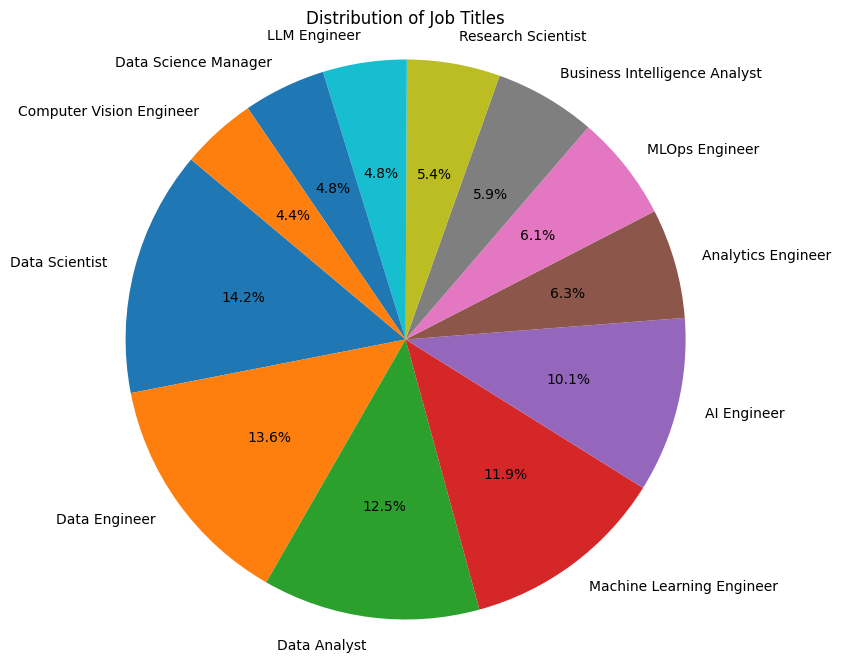

In [9]:
#Pie chart of the distribution of job titles in the dataset
plt.figure(figsize=(10, 8))
plt.pie(df['job_title'].value_counts(), labels=df['job_title'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Job Titles')
plt.axis('equal')
plt.show()

### Findings

1. The job market in this dataset is dominated by Data Scientists, Data Engineers, Data Analysts, and ML Engineer roles, while specialized roles like CV Engineer, Manager, and LLM Engineer are the least common.
1. **Highly imbalanced distribution**:A few roles dominate, while most roles are small slices thus making them valuable in the future and this might make their pay be of higher.


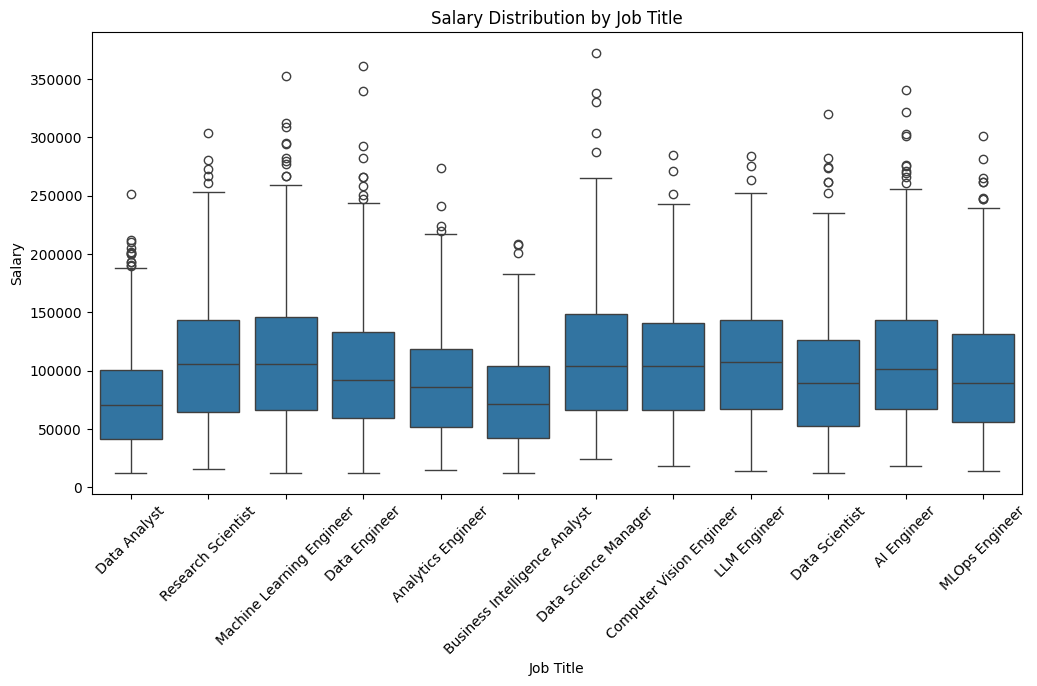

In [10]:
#Box plot of the salary distribution by job title
plt.figure(figsize=(12, 6))
sns.boxplot(x='job_title', y='salary_usd', data=df)
plt.title('Salary Distribution by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.show()


### Findings
1. Management + Emerging AI roles have the highest typical pay.Analyst roles have the lowest typical pay,
1. Even though Data Engineer median is mid ~$95k, it has huge upside.Data Science Manager has both high median and highest max.

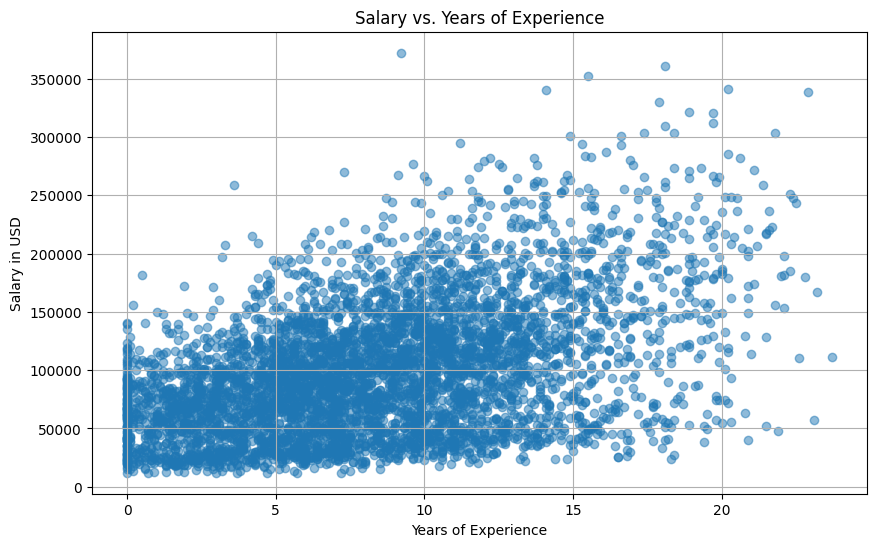

In [11]:
#Scatter plot of salary vs. years of experience
plt.figure(figsize=(10, 6))
plt.scatter(df['years_experience'], df['salary_usd'], alpha=0.5)
plt.title('Salary vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary in USD')
plt.grid()

### Findings
#### 1. ***Overall Trend:Positive but Non-Linear***
* **As years of experience increase, salary tends to increase**.The cloud of points shifts upward from left to right.
* **0-3 years**:Most salaries are clustered between $20k-$120k .Very few points above $150k.
* **5-10 years**:Big jump .Salary range expands to $30k-$220k.Much higher density above $100k.
* **10-20+ years**:Highest salaries appear here .Points reach $250k-$360k.But also still many points in $60k-$120k range.

#### 1. ***High Paying >$150k Threshold***
* **Below 3 years experience**:Almost no dots above $150k.Rare outliers only.
* **3-5 years**:First dots starts crossing $150k.
* **5+ years**:Majority of >$150k salaries appear here density of dots above $150k increases a lot.
* **Peak High Paying Zone: 8-20 years experience**has the most concentration of dots above $200k and $300k.


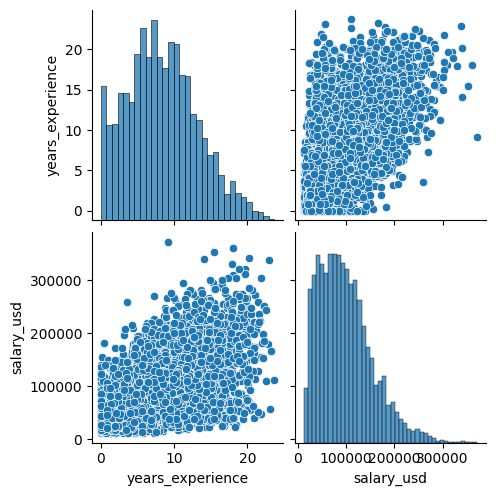

In [12]:
#Pair plot of the numerical features in the dataset
sns.pairplot(df[['years_experience', 'salary_usd']])
plt.show()

## Findings
#### 1. **Distribution of years of experience :Top left Histogram**
* **Shape**:Right-skewed but peaks around 6-10 years.Most peaple in the dataset have 5-12 years of experience.
* **Range**:0-23 years 
* **Very few peaple**:Above 18 years and at 0 years.There is a smaller spike at 0,likely new grades/interns.

#### 2. **Distribution of salary_usd : Bottom Right Histogram**
* **Shape**:Highly right-skewed.Peak is around $60k-$100k.
* **Long tail**:Salaries stretch out to $350k.
* **Most common salary**:$70k-$90k.High Paying >$150k is in the thin right tail.

##  MODELLING

Target Distribution:
target
0    83.56
1    16.44
Name: proportion, dtype: float64 %
Best Params: {'logreg__C': 1, 'logreg__penalty': 'l2'}
Best CV AUC: 0.8433900775561185

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       836
           1       0.36      0.77      0.49       164

    accuracy                           0.74      1000
   macro avg       0.65      0.75      0.66      1000
weighted avg       0.85      0.74      0.77      1000

Test ROC AUC: 0.8273500408449062


c:\Users\frkuhn\anaconda3\envs\HAMPHOLICS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


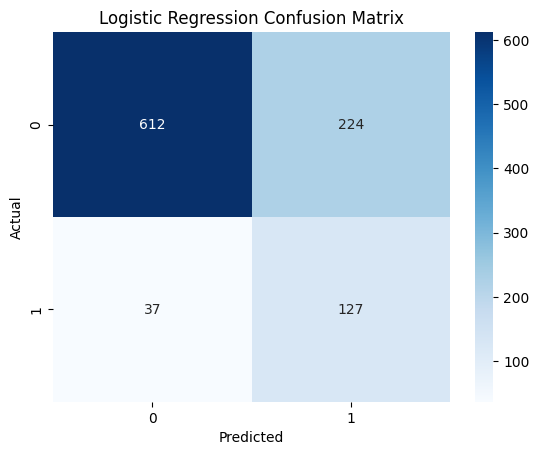

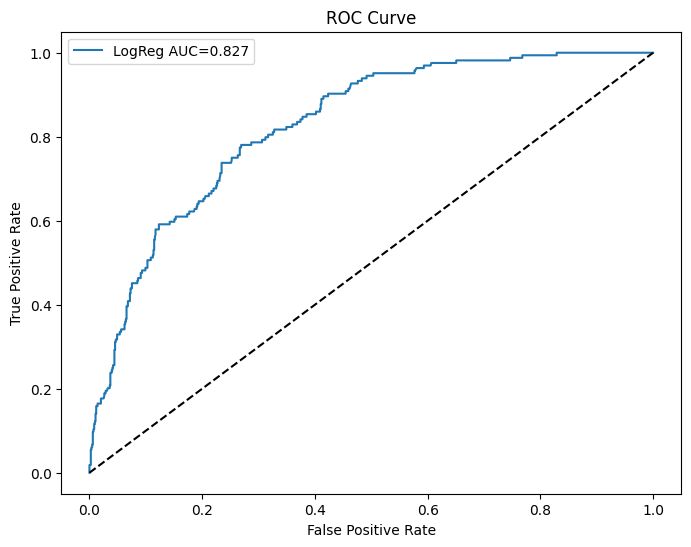


=== Top 10 Features Increasing High Paying Probability ===
                                Feature  Coefficient      Odds
0                      years_experience     1.206573  3.342012
7        job_title_Data Science Manager     0.812343  2.253181
9                job_title_LLM Engineer     0.729535  2.074115
11  job_title_Machine Learning Engineer     0.659971  1.934736
21            employment_type_Full-time     0.594580  1.812270
1                 job_title_AI Engineer     0.550445  1.734025
15             experience_bucket_Senior     0.464896  1.591849
16                       company_size_L     0.403943  1.497719
19             employment_type_Contract     0.319448  1.376368
12         job_title_Research Scientist     0.278312  1.320898

=== Top 10 Features Decreasing High Paying Probability ===
                                    Feature  Coefficient      Odds
6                   job_title_Data Engineer     0.044310  1.045307
17                           company_size_M    -0.345

In [13]:


#  IMPORTING ADDITIONAL LIBRARIES FOR LOGISTIC REGRESSION AND EVALUATION
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

#Create a binary target variable for high-paying jobs

# Target: 1 = High Paying >150k, 0 = Standard Paying
df['target'] = np.where(df['salary_usd'] > 150000, 1, 0)

# Feature engineering from EDA
df['experience_bucket'] = pd.cut(df['years_experience'], 
                                 bins=[-1, 2, 7, 25], 
                                 labels=['Junior', 'Mid', 'Senior'])

print("Target Distribution:")
print(df['target'].value_counts(normalize=True) * 100, "%")

#  FEATURE SELECTION
features = ['job_title', 'salary_usd', 'years_experience', 'experience_bucket', 'company_size', 'employment_type']
X = df[features]
y = df['target']

#  TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  PREPROCESSING PIPELINE 
categorical_features = ['job_title', 'experience_bucket', 'company_size', 'employment_type']
numerical_features = ['years_experience']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Scale years
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Encode job_title
    ])

#LOGISTIC REGRESSION PIPELIN
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

#HYPERPARAMETER TUNING 
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100], # Regularization strength
    'logreg__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(logreg_pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

best_model = grid_search.best_estimator_

# EVALUATION
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("Test ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LogReg AUC={roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# feature importance / coefficients

ohe_features = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_features)

coefs = best_model.named_steps['logreg'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefs})
coef_df['Odds'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("\n=== Top 10 Features Increasing High Paying Probability ===")
print(coef_df.head(10))

print("\n=== Top 10 Features Decreasing High Paying Probability ===")
print(coef_df.tail(10))


=== Linear Regression Results ===
R2 Score: 0.301
MAE: $35,966
RMSE: $46,119
CV R2 Score: 0.330 +/- 0.018


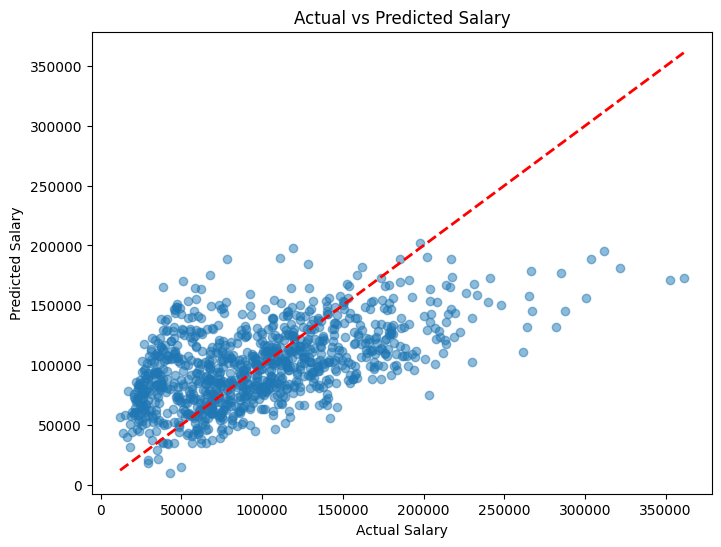

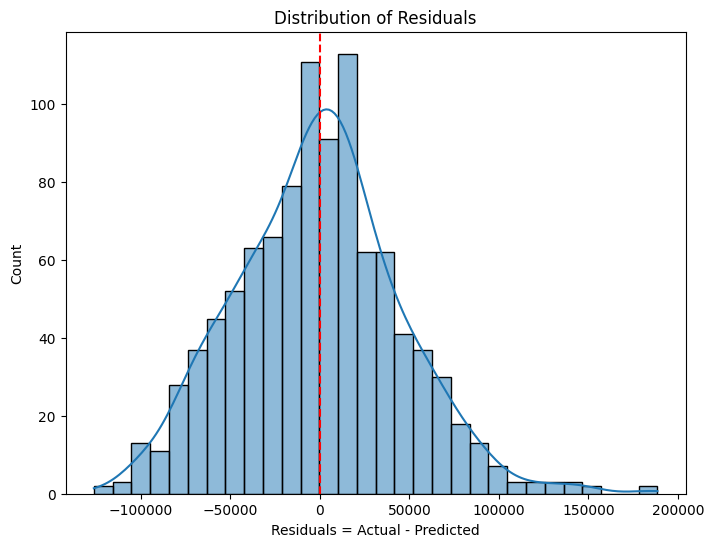


=== Top 10 Features Increasing Salary ===
                                Feature   Coefficient
0                      years_experience  27754.648429
9                job_title_LLM Engineer  16246.343627
21            employment_type_Full-time  16158.380940
16                       company_size_L  15696.331643
7        job_title_Data Science Manager  12941.315724
11  job_title_Machine Learning Engineer  12008.655097
1                 job_title_AI Engineer  10175.789310
19             employment_type_Contract   8902.207907
4    job_title_Computer Vision Engineer   7812.810752
12         job_title_Research Scientist   7251.502154

=== Top 10 Features Decreasing Salary ===
                                    Feature   Coefficient
14                    experience_bucket_Mid  -1193.050610
17                           company_size_M  -1195.166575
6                   job_title_Data Engineer  -1348.788706
15                 experience_bucket_Senior  -3058.872426
8                  job_title_D

In [14]:

#  IMPORTING LIBRARIES
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Feature engineering from EDA
df['experience_bucket'] = pd.cut(df['years_experience'],
                                 bins=[-1, 2, 7, 25], 
                                 labels=['Junior', 'Mid', 'Senior'])

X = df.drop(['salary_usd'], axis=1)
y = df['salary_usd'] # predicting actual salary

# TRAIN-TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# processing pipeline
categorical_features = ['job_title', 'experience_bucket', 'company_size', 'employment_type']
numerical_features = ['years_experience']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# LINEAR REGRESSION PIPELINE 
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train
lr_pipe.fit(X_train, y_train)

# EVALUATION
y_pred = lr_pipe.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Linear Regression Results ===")
print(f"R2 Score: {r2:.3f}") # How much variance explained. 1.0 = perfect
print(f"MAE: ${mae:,.0f}") # Average error in dollars
print(f"RMSE: ${rmse:,.0f}") # Penalizes big errors more

# Cross Validation
cv_scores = cross_val_score(lr_pipe, X, y, cv=5, scoring='r2')
print(f"CV R2 Score: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# PLOTS 
# 1. Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # perfect line
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

# 2. Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Residuals = Actual - Predicted")
plt.title("Distribution of Residuals")
plt.show()

#  FEATURE IMPORTANCE / COEFFICIENTS
# Get feature names after OneHot
ohe_features = lr_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_features)

coefs = lr_pipe.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("\n=== Top 10 Features Increasing Salary ===")
print(coef_df.head(10))

print("\n=== Top 10 Features Decreasing Salary ===")
print(coef_df.tail(10))

# PREDICTING NEW SALARY
new_job = pd.DataFrame({
    'job_title': ['Machine Learning Engineer'],
    'years_experience': [6],
    'experience_bucket': ['Mid'],
    'company_size': ['L'],
    'employment_type': ['FT']
})

predicted_salary = lr_pipe.predict(new_job)[0]
print(f"\nPredicted Salary: ${predicted_salary:,.0f}")

In [ ]:

# IMPORTING ADDITIONAL LIBRARIES FOR RANDOM FOREST AND EVALUATION
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# Target: 1 = High Paying >150k, 0 = Standard Paying
df['target'] = np.where(df['salary_usd'] > 150000, 1, 0)

# Feature engineering
df['experience_bucket'] = pd.cut(df['years_experience'], 
                                 bins=[-1, 2, 7, 25], 
                                 labels=['Junior', 'Mid', 'Senior'])

print("Target Distribution:")
print(df['target'].value_counts(normalize=True) * 100, "%")

#  FEATURES + SPLIT
features = ['job_title', 'years_experience', 'experience_bucket', 'company_size', 'employment_type']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# PREPROCESSING 
# RandomForest doesn't need scaling, but still needs OneHot for categories
categorical_features = ['job_title', 'experience_bucket', 'company_size', 'employment_type']
numerical_features = ['years_experience']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features), # no scaling needed
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# RANDOM FOREST PIPELINE 
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# HYPERPARAMETER TUNING 
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

best_model = grid_search.best_estimator_

#EVALUATION
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("Test ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest AUC={roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# STEP 7: FEATURE IMPORTANCE 
# Get feature names after OneHot
ohe_features = best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_features)

importances = best_model.named_steps['rf'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

print("\nTop 10 Important Features:")
print(feat_imp_df.head(10))

#PREDICT NEW JOB
new_job = pd.DataFrame({
    'job_title': ['Machine Learning Engineer'],
    'years_experience': [6],
    'experience_bucket': ['Mid'],
    'company_size': ['L'],
    'employment_type': ['FT']
})

prob = best_model.predict_proba(new_job)[0,1]
print(f"\nProbability of High Paying >150k: {prob*100:.1f}%")
if prob > 0.5:
    print("Prediction: HIGH PAYING JOB")
else:
    print("Prediction: STANDARD PAYING JOB")

Target Distribution:
target
0    83.56
1    16.44
Name: proportion, dtype: float64 %
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='roc_auc')
print(f"CV AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

CV AUC: 0.827 +/- 0.014


##  Conclusions And Recommendations

### A. Conclusions

Based on the EDA and modeling of AI/Data Science roles in 2026:

1. **Experience is the primary salary driver**  
   Salary increases with **years_experience**, but the jump is non-linear. The biggest leap happens after **5 years**.  
   The "peak earning zone" is **8-20 years**, where most salaries of **$200k-$300k** occur.  
   Roles with **<3 years** experience rarely exceed **$150k**.

2. **Job Title defines pay tiers**  
   The market is dominated by **Data Scientist, Data Engineer, Data Analyst, and ML Engineer**.  
   However, the highest pay is not in the most common roles.  
   - **Top paying**: *Business Intelligence Analyst, ML Engineer, Research Scientist, Data Science Manager* 
   - **Lowest paying**: *Data Analyst, Analytics Engineer, `BI Analyst* 
   Emerging roles like **LLM Engineer** already command premium salaries despite being rare at **4.8%**.

3. **Company context matters**  
   - **Positive drivers**: **Full-time roles** and **Large companies** 
   - **Negative drivers**: **Part-time** and **Small companies** 
   These were among the strongest predictors in both classification and regression models.

4. **High-paying roles are a minority and hard to predict perfectly**
   - Only **16.44%** of jobs are >$150k → class imbalance
   - **Classification Model**: ROC AUC = **0.827**, Accuracy = **74%**. High recall **0.77** but low precision **0.36** for high-paying class.
   - **Regression Model**: R² = **0.30**, MAE = **$35,966**. ~70% of salary variance is unexplained by current features.


### B. Recommendations

#### 1. For Job Seekers
- **Target high-leverage titles**: Prioritize career paths toward **Data Science Manager**, **LLM Engineer**, **ML Engineer**, and **Research Scientist**.
- **Invest in 5+ years of experience**: This is the critical threshold to break into the >$150k bracket. Focus on specialization between years 3-8.
- **Aim for Full-time roles at Large companies**: These two factors significantly increase odds of high pay.

#### 2. For Companies & Hiring Managers
- **Pay premiums for emerging AI skills**: Roles like **LLM Engineer** are rare now but already top paid. Early investment helps attract talent.
- **Benchmark against title + experience bands**: Use the 8-20 year experience band as the guide for senior/principal compensation. 
- **Address the analyst pay gap**: **Data Analyst** and **BI Analyst** roles are common but lowest paid. Create upskilling paths to ML/Research to retain talent.

